**Ciência de Dados**

Prof. Miguel Bozer da Silva - miguel.bozer@senaisp.edu.br

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from googledrivedownloader import download_file_from_google_drive as gdd

# 1. Recebendo os dados

**a) Carregar os dados do arquivo "penguins_size.csv" para que seja possível realizar uma análise desse conjunto de dados.**

In [9]:
data_google_id = "1FC9l4aV5Trf7M_VRtcvvt8-PUkKx5751"
gdd(file_id=data_google_id, dest_path="./penguins_size.csv", showsize=True, overwrite=True)
dados = pd.read_csv("./penguins_size.csv")

0.0 B Done.


**b) Verificar as informações contidas nesse conjunto de dados visualizando as 5 primeiras linhas e os tipos de dados de cada coluna.**

In [10]:
dados.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [12]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


#2. Verificando valores nulos

Verificar por valores nulos que existam nesse conjunto de dados. Caso existir valores nulos, excluir as linhas com essas entradas.

In [13]:
dados.isna().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [20]:
dados_limpos = dados.dropna()

In [21]:
dados_limpos.isna().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


# 3. Gráficos e agrupamentos

**a) Quantas espécies e ilhas diferentes temos nesse conjunto de dados? Verifique também os diferentes valores possíveis que temos no sexo dos pinguins. Existe algum problema nessa coluna?**

In [29]:
dados_limpos["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [28]:
dados_limpos["island"].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [31]:
dados_limpos["sex"].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [32]:
mask = dados_limpos["sex"] == "."
dados_limpos[mask]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [34]:
dados_limpos.drop(index=336, inplace=True)

/tmp/ipykernel_527/252495768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_limpos.drop(index=336, inplace=True)


In [35]:
dados_limpos["sex"].unique()

array(['MALE', 'FEMALE'], dtype=object)

**b) Crie uma gráfico de barras para visualizarmos a frequência de pinguins em suas diferentes espécies**

**c) Crie uma gráfico de barras para visualizarmos a frequência de pinguins em suas diferentes ilhas**

**d) Crie uma gráfico de barras para visualizarmos a frequência de pinguins em seus diferentes sexos.**

**Obs.: O código abaixo deve ser executado antes de criarmos o gráfico para substituir o '.' pelo genero FEMALE. Iremos ver isso posteriormente em mais detalhes durante as aulas.**

**e) Crie um agrupamento em que seja possível visualizarmos a média de peso dos pinguins por espécie e por ilha.**

In [36]:
dados_limpos.groupby(by=['species', 'island'])['body_mass_g'].mean()

species    island   
Adelie     Biscoe       3709.659091
           Dream        3701.363636
           Torgersen    3708.510638
Chinstrap  Dream        3733.088235
Gentoo     Biscoe       5092.436975
Name: body_mass_g, dtype: float64

Existem pinguins de diferentes espécies em todas as ilhas? Qual a espécie de pinguim que possui a maior média de peso e em qual ilha ele se encontra?

**f) Crie um histograma para visualizarmos a distribuição do peso dos pinguins por cada uma das suas diferentes espécies**

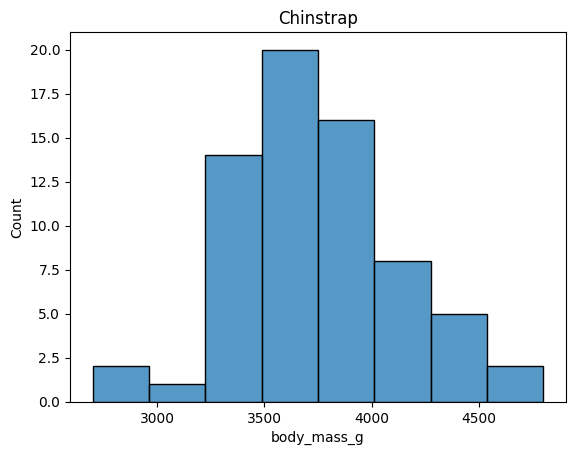

In [38]:
maska = dados_limpos['species'] == 'Chinstrap'
n_cols = 8
sns.histplot(data= dados_limpos[maska]['body_mass_g'], bins=n_cols)
plt.title('Chinstrap')
plt.show()

O que você consegue concluir a partir dos histogramas que foram criados?

**g) Crie um gráfico de dispersão onde temos o culmen_length_mm no eixo x e o culmen_depth_mm no eixo y. Faça com que as cores de cada ponto do gráfico seja destacado pela espécie de pinguim**

Existe alguma diferença entre as diferentes espécies de pinguins a partir do gráfico obtido anteriormente?